<a href="https://colab.research.google.com/github/YounesElMajdoubi/License_Plate_Deblurring/blob/main/code/License_Plate_Deblurring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Running Simulation Pipeline ---

--- Running Real-World Pipeline ---


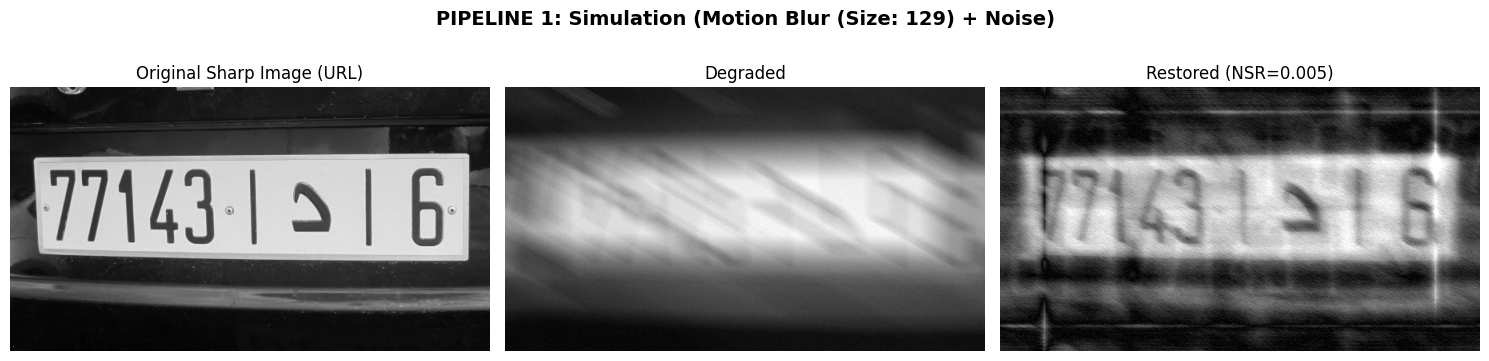

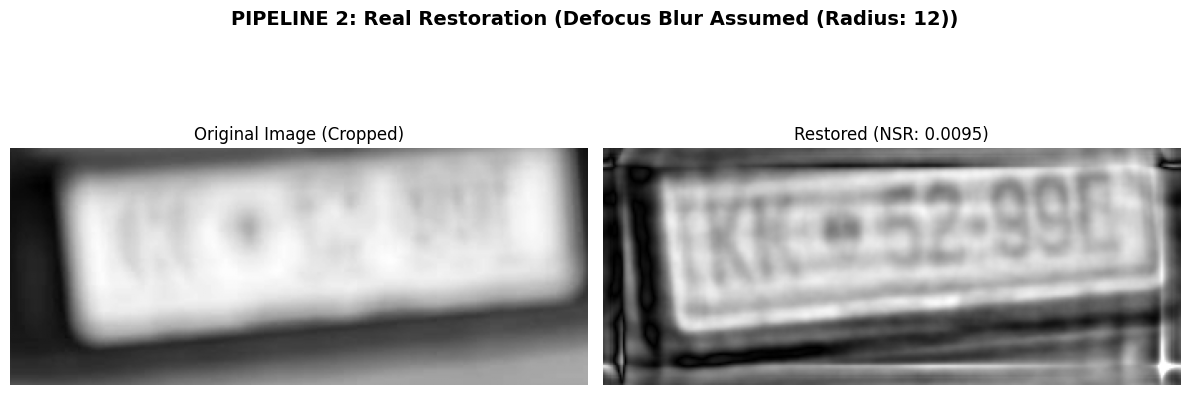

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ==========================================
# 1. Kernel Generation Functions (PSF)
# ==========================================

def create_motion_blur_kernel(size, angle):
    """Creates a linear motion blur kernel (PSF)."""
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    angle_rad = np.deg2rad(angle)
    x = int(np.cos(angle_rad) * center)
    y = int(np.sin(angle_rad) * center)

    cv2.line(kernel, (center - x, center - y), (center + x, center + y), 1, thickness=1)
    kernel /= np.sum(kernel)
    return kernel

def create_defocus_kernel(radius):
    """Creates a circular defocus (out-of-focus) kernel."""
    if radius == 0:
        return np.ones((1, 1), dtype=np.float32)
    size = 2 * radius + 1
    kernel = np.zeros((size, size), dtype=np.float32)
    center = radius

    cv2.circle(kernel, (center, center), radius, 1, thickness=-1)
    kernel /= np.sum(kernel)
    return kernel

# ==========================================
# 2. Degradation & Restoration Functions
# ==========================================

def apply_blur_and_noise(image, kernel, noise_var):
    """Applies the PSF to the image and adds Gaussian noise."""
    blurred = cv2.filter2D(image, -1, kernel)

    row, col = image.shape
    mean = 0
    sigma = noise_var ** 0.5
    gauss = np.random.normal(mean, sigma, (row, col))

    noisy_blurred = blurred + gauss
    return np.clip(noisy_blurred, 0, 255).astype(np.uint8)

def wiener_deconvolution(blurred_img, kernel, nsr_lambda):
    """Applies Wiener Deconvolution in the Frequency Domain."""
    h_img, w_img = blurred_img.shape
    h_ker, w_ker = kernel.shape

    pad_h = h_img - h_ker
    pad_w = w_img - w_ker
    padded_kernel = np.pad(kernel, ((0, pad_h), (0, pad_w)), 'constant')

    G = np.fft.fft2(blurred_img)
    H = np.fft.fft2(padded_kernel)

    H_conj = np.conj(H)
    H_squared_mag = np.abs(H) ** 2

    W = H_conj / (H_squared_mag + nsr_lambda)
    F_prime = G * W

    f_prime_spatial = np.abs(np.fft.ifft2(F_prime))

    # Correct shift to recenter the image
    shift_y, shift_x = h_ker // 2, w_ker // 2
    f_prime_spatial = np.roll(f_prime_spatial, shift_y, axis=0)
    f_prime_spatial = np.roll(f_prime_spatial, shift_x, axis=1)

    return np.clip(f_prime_spatial, 0, 255).astype(np.uint8)

def fetch_image_safely(url):
    """Fetches an image with a User-Agent to prevent 403 Forbidden errors."""
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
        return cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

# ==========================================
# Main Execution
# ==========================================
if __name__ == "__main__":

    # ==========================================
    # PIPELINE 1: SIMULATION
    # ==========================================
    print("--- Running Simulation Pipeline ---")
    sim_url = "https://licenseplatemania.com/landenvolledig/marokko/marokko_6.jpg"

    try:
        sim_image = fetch_image_safely(sim_url)

        if sim_image is not None:
            # --- SIMULATION CONFIGURATION HUB ---
            SIM_BLUR_TYPE = 'motion'  # Toggle this to 'motion' or 'defocus'

            sim_noise_variance = 5.0
            sim_nsr_lambda = 0.005

            if SIM_BLUR_TYPE == 'motion':
                sim_blur_size = 129
                sim_blur_angle = 30
                sim_psf = create_motion_blur_kernel(sim_blur_size, sim_blur_angle)
                blur_title = f"Motion Blur (Size: {sim_blur_size})"
            elif SIM_BLUR_TYPE == 'defocus':
                sim_radius = 15
                sim_psf = create_defocus_kernel(sim_radius)
                blur_title = f"Defocus Blur (Radius: {sim_radius})"
            else:
                raise ValueError("Invalid SIM_BLUR_TYPE")
            # ------------------------------------

            sim_degraded = apply_blur_and_noise(sim_image, sim_psf, sim_noise_variance)
            sim_restored = wiener_deconvolution(sim_degraded, sim_psf, sim_nsr_lambda)

            plt.figure(figsize=(15, 4))
            plt.suptitle(f"PIPELINE 1: Simulation ({blur_title} + Noise)", fontsize=14, fontweight='bold')

            plt.subplot(1, 3, 1)
            plt.title("Original Sharp Image (URL)")
            plt.imshow(sim_image, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Degraded")
            plt.imshow(sim_degraded, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title(f"Restored (NSR={sim_nsr_lambda})")
            plt.imshow(sim_restored, cmap='gray')
            plt.axis('off')

            plt.tight_layout()
        else:
            print("Error: Could not decode the simulation image.")
    except Exception as e:
        print(f"Error in Pipeline 1: {e}")


    # ==========================================
    # PIPELINE 2: REAL-WORLD
    # ==========================================
    print("\n--- Running Real-World Pipeline ---")
    real_url = "https://blog.ampedsoftware.com/wp-content/uploads/2023/10/image7-1.jpg"

    try:
        real_image_full = fetch_image_safely(real_url)

        if real_image_full is not None:
            # Crop to the plate (using your provided dimensions)
            h, w = real_image_full.shape
            cropped_plate = real_image_full[int(h*0.43):int(h*0.64), int(w*0.39):int(w*0.73)]

            # --- REAL-WORLD CONFIGURATION HUB ---
            REAL_BLUR_TYPE = 'defocus'  # Toggle this to 'motion' or 'defocus'

            real_nsr_lambda = 0.0095

            if REAL_BLUR_TYPE == 'motion':
                real_blur_size = 35 # Adjust based on the actual image
                real_blur_angle = 0
                real_psf = create_motion_blur_kernel(real_blur_size, real_blur_angle)
                real_blur_title = f"Motion Blur Assumed (Size: {real_blur_size})"
            elif REAL_BLUR_TYPE == 'defocus':
                real_guessed_radius = 12 # Adjust based on the actual image
                real_psf = create_defocus_kernel(real_guessed_radius)
                real_blur_title = f"Defocus Blur Assumed (Radius: {real_guessed_radius})"
            else:
                raise ValueError("Invalid REAL_BLUR_TYPE")
            # ------------------------------------

            real_restored = wiener_deconvolution(cropped_plate, real_psf, real_nsr_lambda)

            plt.figure(figsize=(12, 5))
            plt.suptitle(f"PIPELINE 2: Real Restoration ({real_blur_title})", fontsize=14, fontweight='bold')

            plt.subplot(1, 2, 1)
            plt.title("Original Image (Cropped)")
            plt.imshow(cropped_plate, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.title(f"Restored (NSR: {real_nsr_lambda})")
            plt.imshow(real_restored, cmap='gray')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

        else:
            print("Error: Could not decode the real image.")

    except Exception as e:
        print(f"Error in Pipeline 2: {e}")